In [7]:
import pandas as pd

transcript_path = r"C:\Users\calvo\dev\mlh2026-altur\data\SF_transcripts.csv"
label_path = r"C:\Users\calvo\dev\mlh2026-altur\data\manifest.csv"

transcript_df = pd.read_csv(transcript_path)
label_df = pd.read_csv(label_path)

# Remove .wav to match the anon_id format
transcript_df["id"] = transcript_df["FILE_NAME"].str.replace(
    ".wav", "", regex=False
)

# Match transcript_df.id with label_df.anon_id
df = pd.merge(
    transcript_df,
    label_df,
    left_on="id",
    right_on="anon_id",
    how="left"
)

df = df[
    [
        "FULL_TEXT",
        "CHANNEL0_TEXT",
        "CHANNEL1_TEXT",
        "anon_id",
        "label",
        "split",
        "duration_s"
    ]
].rename(columns={
    "anon_id": "ANON_ID",
    "label": "LABEL"
})

df.head()

,FULL_TEXT,CHANNEL0_TEXT,CHANNEL1_TEXT,ANON_ID,LABEL,split,duration_s
0,"Buen día, gracias por llamar a Banco Altur. Le...","Hola, buenas tardes. Mire, le llamo porque est...","Buen día, gracias por llamar a Banco Altur. Le...",call_0181ce113ebe,synthetic,train,170
1,"Buen día, gracias por llamar a Banco Altur. Le...","Buen día, Marina. Mira, te llamo porque tengo ...","Buen día, gracias por llamar a Banco Altur. Le...",call_018c9d3823ac,synthetic,train,128
2,"Buen día, gracias por llamar a Banco Altur, le...","Hola, buenas tardes. Oye, fíjate que cambié de...","Buen día, gracias por llamar a Banco Altur, le...",call_01bf49059daf,synthetic,train,216
3,"Buen día, gracias por llamar a Banco Altur. Le...","Buenas tardes, hablo porque metí una solicitud...","Buen día, gracias por llamar a Banco Altur. Le...",call_01c3806808d6,synthetic,train,149
4,"Buen día, gracias por llamar a Banco Altur. Le...","Hola, Marina. Ajá. Sí, quiero saber cuánto deb...","Buen día, gracias por llamar a Banco Altur. Le...",call_0294f969f98b,synthetic,val,109


In [9]:
from collections import Counter
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download("stopwords", quiet=True)
nltk.download("vader_lexicon", quiet=True)

stop_words = set(stopwords.words("spanish"))
sia = SentimentIntensityAnalyzer()

def get_words(text):
  words = re.findall(r"\b[a-zA-Z]{2,}\b", str(text).lower())
  return [word for word in words if word not in stop_words]

# Keep human and synthetic labels
channel_df = df[
  df["LABEL"].astype(str).str.lower().isin(["human", "synthetic"])
].copy()

# Most common words by label
common_words = {}

for label, group in channel_df.groupby(channel_df["LABEL"].str.lower()):
  words = [
    word
    for text in group["CHANNEL0_TEXT"].fillna("")
    for word in get_words(text)
  ]
  common_words[label] = pd.DataFrame(
    Counter(words).most_common(20),
    columns=["word", "count"]
  )

for label, words_df in common_words.items():
  print(f"\nMost common words for {label}:")
  display(words_df)

# Sentiment analysis for channel 0
sentiment_scores = channel_df["CHANNEL0_TEXT"].fillna("").apply(
  lambda text: sia.polarity_scores(text)["compound"]
)

channel_df["sentiment_score"] = sentiment_scores
channel_df["sentiment"] = channel_df["sentiment_score"].apply(
  lambda score: (
    "positive" if score >= 0.05
    else "negative" if score <= -0.05
    else "neutral"
  )
)

sentiment_summary = (
  channel_df.groupby(channel_df["LABEL"].str.lower())
  .agg(
    mean_sentiment=("sentiment_score", "mean"),
    positive=("sentiment", lambda x: (x == "positive").sum()),
    neutral=("sentiment", lambda x: (x == "neutral").sum()),
    negative=("sentiment", lambda x: (x == "negative").sum()),
  )
  .reset_index()
  .rename(columns={"LABEL": "label"})
)

display(sentiment_summary)


Most common words for human:


,word,count
0,gracias,108
1,quiero,103
2,tarjeta,86
3,cargo,81
4,hola,78
5,saber,74
6,agosto,67
7,correcto,66
8,dos,63
9,si,60



Most common words for synthetic:


,word,count
0,claro,246
1,gracias,176
2,referencia,161
3,cuenta,161
4,si,159
5,hola,146
6,tarjeta,145
7,marina,140
8,pago,126
9,quiero,122


,label,mean_sentiment,positive,neutral,negative
0,human,-0.556107,4,4,142
1,synthetic,-0.563604,10,10,183


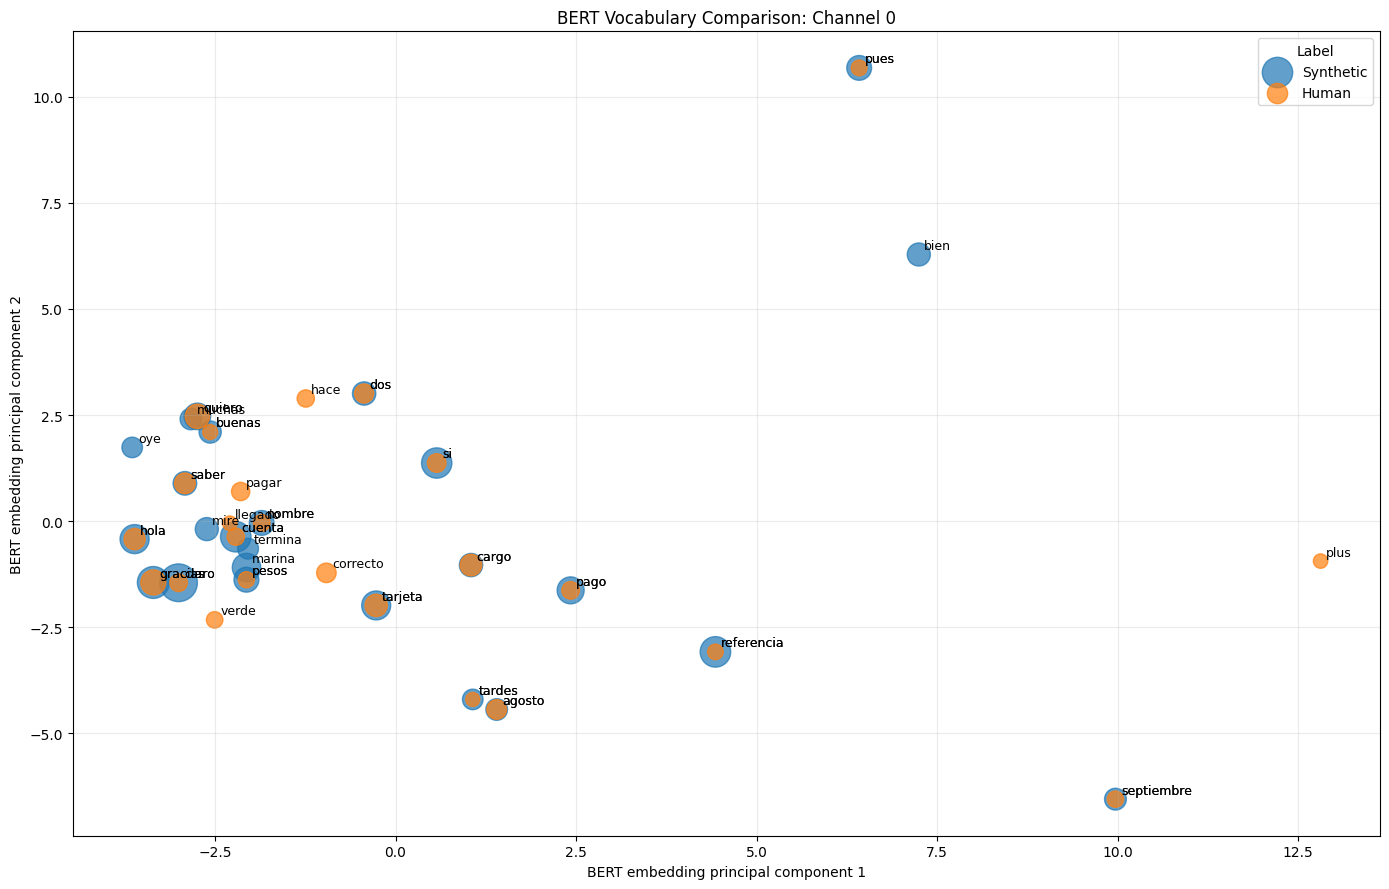

In [11]:
import torch

import matplotlib.pyplot as plt

# Build channel 0 vocabularies by label
vocab_by_label = {}

for label in ["synthetic", "human"]:
  texts = channel_df.loc[
    channel_df["LABEL"].str.lower() == label,
    "CHANNEL0_TEXT"
  ].fillna("")

  counts = Counter(
    word
    for text in texts
    for word in get_words(text)
  )

  vocab_by_label[label] = dict(counts.most_common(25))

# Embed unique vocabulary words with BERT
words = sorted(set().union(*[set(v) for v in vocab_by_label.values()]))

device = next(bert_model.parameters()).device
inputs = tokenizer(
  words,
  return_tensors="pt",
  padding=True,
  truncation=True
)
inputs = {key: value.to(device) for key, value in inputs.items()}

bert_model.eval()
with torch.no_grad():
  outputs = bert_model(**inputs)
  word_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()

# Project embeddings into two dimensions
pca_vocab = PCA(n_components=2, random_state=42)
coordinates = pca_vocab.fit_transform(word_embeddings)

word_coordinates = {
  word: coordinate for word, coordinate in zip(words, coordinates)
}

# Plot vocabulary comparison
plt.figure(figsize=(14, 9))

colors = {
  "synthetic": "tab:blue",
  "human": "tab:orange"
}

for label, vocabulary in vocab_by_label.items():
  x = [word_coordinates[word][0] for word in vocabulary]
  y = [word_coordinates[word][1] for word in vocabulary]
  sizes = [vocabulary[word] * 3 for word in vocabulary]

  plt.scatter(
    x,
    y,
    s=sizes,
    alpha=0.7,
    c=colors[label],
    label=label.capitalize()
  )

  for word in vocabulary:
    px, py = word_coordinates[word]
    plt.annotate(
      word,
      (px, py),
      xytext=(4, 4),
      textcoords="offset points",
      fontsize=9
    )

plt.title("BERT Vocabulary Comparison: Channel 0")
plt.xlabel("BERT embedding principal component 1")
plt.ylabel("BERT embedding principal component 2")
plt.legend(title="Label")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

ImportError: cannot import name 'Sentinel' from 'typing_extensions' (C:\Users\calvo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\typing_extensions.py)